# 使用 PROC OPTMODEL 最小化作业车间的完工时间（Makespan）


## 执行摘要

一个小型离散制造单元需要将四个零件——一个 **Bracket（支架）**、一个 **Flange（法兰）**、一个 **Housing（外壳）** 和一个 **Shaft（轴）**——各自通过固定顺序的三道机加工工序，它们共享四台单一产能的机器（**Saw（锯床）**、**Mill（铣床）**、**Drill（钻床）**、**Grind（磨床）**）。任何一台机器都不能同时运行两道工序，而且每个零件的各道工序必须遵循其工艺顺序。我们将完工时间最小化的调度问题构造为一个混合整数规划模型，在 **PROC OPTMODEL** 中求解——包括开始时间变量、完工到开始的先后次序约束，以及在每一对共享同一机器的工序之间设置的析取（大-*M*）互不重叠约束——并将其求解至可证明的最优。

MILP 求解器返回了 **120 分钟的最优完工时间**（`Solution Status = Optimal`，`Objective Value = 120`）。所得到的调度将全部十二道工序紧凑排布，使得每台机器在任一时刻至多处理一个零件，并且每个零件都按其要求的顺序在 Grind 之前完成 Saw/Mill/Drill 加工。有两道工序恰好在第 120 分钟结束——Bracket 的磨削和 Housing 的铣削——因此 Grind 和 Mill 这两台机器都位于决定调度总长度的关键路径上。

## 数据来源

所有数据均在 notebook 内部定义——不涉及外部文件或网络。

| 数据集 | 行数 | 关键变量 | 说明 |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`、`job`、`opnum`、`machine`、`dur`、`jobname`、`mname` | 每道工序一行（4 个零件 × 3 道工序）。`machine`（1–4）是该工序所需的机器；`dur` 是其加工时间（分钟）；`jobname`/`mname` 是可读的零件与机器标签。 |
| `sched` | 12 | `op`、`start`、`finish` | OPTMODEL 的输出：每道工序的最优开始与结束分钟。 |
| `schedule` | 12 | `jobname`、`opnum`、`mname`、`dur`、`start`、`finish` | 将 `jobshop` 与求解得到的时间合并，按机器再按开始时间排序——即人类可读的调度表。 |
| `mk` | 1 | `makespan` | 实现的完工时间（最晚的结束时间）。 |

## 调度问题

在**作业车间（job shop）**中，若干零件（"作业"）各自经过一个固定顺序的工序序列，而每道工序运行在一台特定的机器上。两道工序不能在同一时刻占用同一台机器（机器是*一元（unary）*资源），并且同一零件内部的各道工序必须遵循其工艺顺序。计划者希望为每道工序确定开始时间，在满足这两条规则的同时，使调度总长度——即**完工时间（makespan）**——尽可能小。

这是一个经典的析取调度问题。我们将其建模为一个混合整数规划：

- 为每道工序设一个连续但取整数值的**开始时间** `s[o]`，以及一个完工时间变量 `Cmax`；
- **先后次序**：某零件的第 *k+1* 道工序开始时间不早于第 *k* 道工序结束时间；
- **析取式机器产能**：对于每一对共享同一机器的工序，用一个二元变量 `y` 决定谁先谁后，并用一个大-*M* 项关闭未激活的排序——从而使这两道工序永远不会重叠；
- **目标**：最小化 `Cmax`，它被强制不小于每道工序的结束时间。

PROC OPTMODEL 是 SAS/OR 的代数建模过程；其 MILP 求解器可以找到*可证明最优*的最短调度。

> **关于 PROC CLP 的说明。** SAS 也提供 PROC CLP，一个具有专用调度语法（活动、资源、先后次序）的约束逻辑 > 编程引擎。此处的 OPTMODEL MILP 构造求解的是完全 > 相同的问题，并返回最优性证书，而 CLP 的 > 可行性搜索并不提供这一点。

## 步骤 1 — 定义车间实例

四个零件，每个三道工序，在四台机器上加工。每一行确定一道工序所需的机器及其加工时间（分钟）。同一零件的各道工序按工艺顺序列出（`opnum` 为 1、2、3）。

In [1]:
数据 jobshop;
    长度 jobname $10 mname $6;
    输入 op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Bracket  Saw
2  1 2 3 40 Bracket  Drill
3  1 3 4 20 Bracket  Grind
4  2 1 2 35 Flange   Mill
5  2 2 3 25 Flange   Drill
6  2 3 1 15 Flange   Saw
7  3 1 3 30 Housing  Drill
8  3 2 1 20 Housing  Saw
9  3 3 2 45 Housing  Mill
10 4 1 1 20 Shaft    Saw
11 4 2 2 30 Shaft    Mill
12 4 3 4 25 Shaft    Grind
;
运行;

过程 打印 数据=jobshop noobs 标签;
    标题 '作业车间实例：4 个零件，每个 3 道工序，共 4 台机器';
    变量 op jobname opnum mname dur;
    标签 op='工序' jobname='零件' opnum='工序序号'
          mname='机器' dur='加工时间(分钟)';
运行;

                                             作业车间实例：4 个零件，每个 3 道工序，共 4 台机器                                              

    工序       零件          工序序号      机器              加工时间(分钟)
     1  Bracket             1  Saw                       25
     2  Bracket             2  Drill                     40
     3  Bracket             3  Grind                     20
     4  Flange              1  Mill                      35
     5  Flange              2  Drill                     25
     6  Flange              3  Saw                       15
     7  Housing             1  Drill                     30
     8  Housing             2  Saw                       20
     9  Housing             3  Mill                      45
    10  Shaft               1  Saw                       20
    11  Shaft               2  Mill                      30
    12  Shaft               3  Grind                     25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## 步骤 2 — 用 PROC OPTMODEL 求解完工时间最小化的调度

OPTMODEL 读取实例，构建开始时间与排序变量，设置先后次序约束和析取约束，并用其 MILP 求解器最小化完工时间。大-*M* 时间跨度 `H` 是总工作量——任意开始时间的一个安全上界。求解器报告**最优**目标值；我们将选定的开始与结束时间写入 `sched`。

In [2]:
过程 optmodel;
    设置 OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ 数据 jobshop INTO OPS=[op] job opnum machine dur;

    /* 安全的大-M 时间跨度 = 总工作量 */
    num H = sum{o IN OPS} dur[o];

    变量 s{OPS} >= 0 integer;     /* 工序开始时间（分钟） */
    变量 Cmax >= 0;               /* 完工时间 makespan */

    /* 工艺顺序：第 k+1 道工序在第 k 道工序完成后开始 */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] 并且 opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* 完工时间不小于每一道工序的结束时间 */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* 析取式机器产能：对每一对共享同一机器的工序，二元变量 y
       固定其先后次序；大-M 项关闭未激活的排序 */
    变量 y{a IN OPS, b IN OPS:
          a < b 并且 machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b 并且 machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b 并且 machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREATE 数据 sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                                             作业车间实例：4 个零件，每个 3 道工序，共 4 台机器                                              


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## 步骤 3 — 组装可读的调度表

将求解得到的时间合并回零件与机器标签上，先按机器再按开始时间排序，并打印调度表。完工时间是所有工序中最大的结束时间。

In [3]:
过程 排序 数据=jobshop out=jobs2; 按照 op; 运行;
过程 排序 数据=sched   out=sol;   按照 op; 运行;

数据 schedule;
    合并 jobs2 sol;
    按照 op;
运行;

过程 排序 数据=schedule; 按照 mname START; 运行;

过程 打印 数据=schedule noobs 标签;
    标题 '最优调度：每道工序的开始/结束时间（分钟）';
    变量 jobname opnum mname dur START FINISH;
    标签 jobname='零件' opnum='工序序号' mname='机器'
          dur='加工时间(分钟)' START='开始时间' FINISH='结束时间';
运行;

过程 均值 数据=schedule MAX NOPRINT;
    变量 FINISH;
    输出 out=mk(删除=_type_ _freq_) MAX=makespan;
运行;

过程 打印 数据=mk noobs 标签;
    标题 '最小完工时间（最晚工序结束，分钟）';
    标签 makespan='完工时间(分钟)';
运行;

                                                 最优调度：每道工序的开始/结束时间（分钟）                                                  

     零件          工序序号      机器              加工时间(分钟)          开始时间          结束时间
Housing             1  Drill                     30             0            30
Flange              2  Drill                     25            35            60
Bracket             2  Drill                     40            60           100
Shaft               3  Grind                     25            65            90
Bracket             3  Grind                     20           100           120
Flange              1  Mill                      35             0            35
Shaft               2  Mill                      30            35            65
Housing             3  Mill                      45            75           120
Shaft               1  Saw                       20             0            20
Bracket             1  Saw                       25            20            4


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## 步骤 4 — 可视化调度

我们为每道工序赋予一个序数**槽位（slot）**（先按机器、再按开始时间排序），并将其时间窗口绘制为一个浮动条：该条从工序的开始分钟延伸到结束分钟。槽位 1–3 是 Drill，4–5 是 Grind，6–8 是 Mill，9–12 是 Saw。正下方的表格标出每个槽位中的零件名，因此图表与表格可以对照阅读。同一台机器上的条形在时间上从不重叠——这就是析取约束的可视化呈现。

                                                 按槽位排列的调度（槽位顺序与下方图表一致）                                                  

    槽位      机器       零件          开始时间          结束时间
     1  Drill   Housing             0            30
     2  Drill   Flange             35            60
     3  Drill   Bracket            60           100
     4  Grind   Shaft              65            90
     5  Grind   Bracket           100           120
     6  Mill    Flange              0            35
     7  Mill    Shaft              35            65
     8  Mill    Housing            75           120
     9  Saw     Shaft               0            20
    10  Saw     Bracket            20            45
    11  Saw     Housing            45            65
    12  Saw     Flange             65            80

                                                 按槽位排列的调度（槽位顺序与下方图表一致）                                                  




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


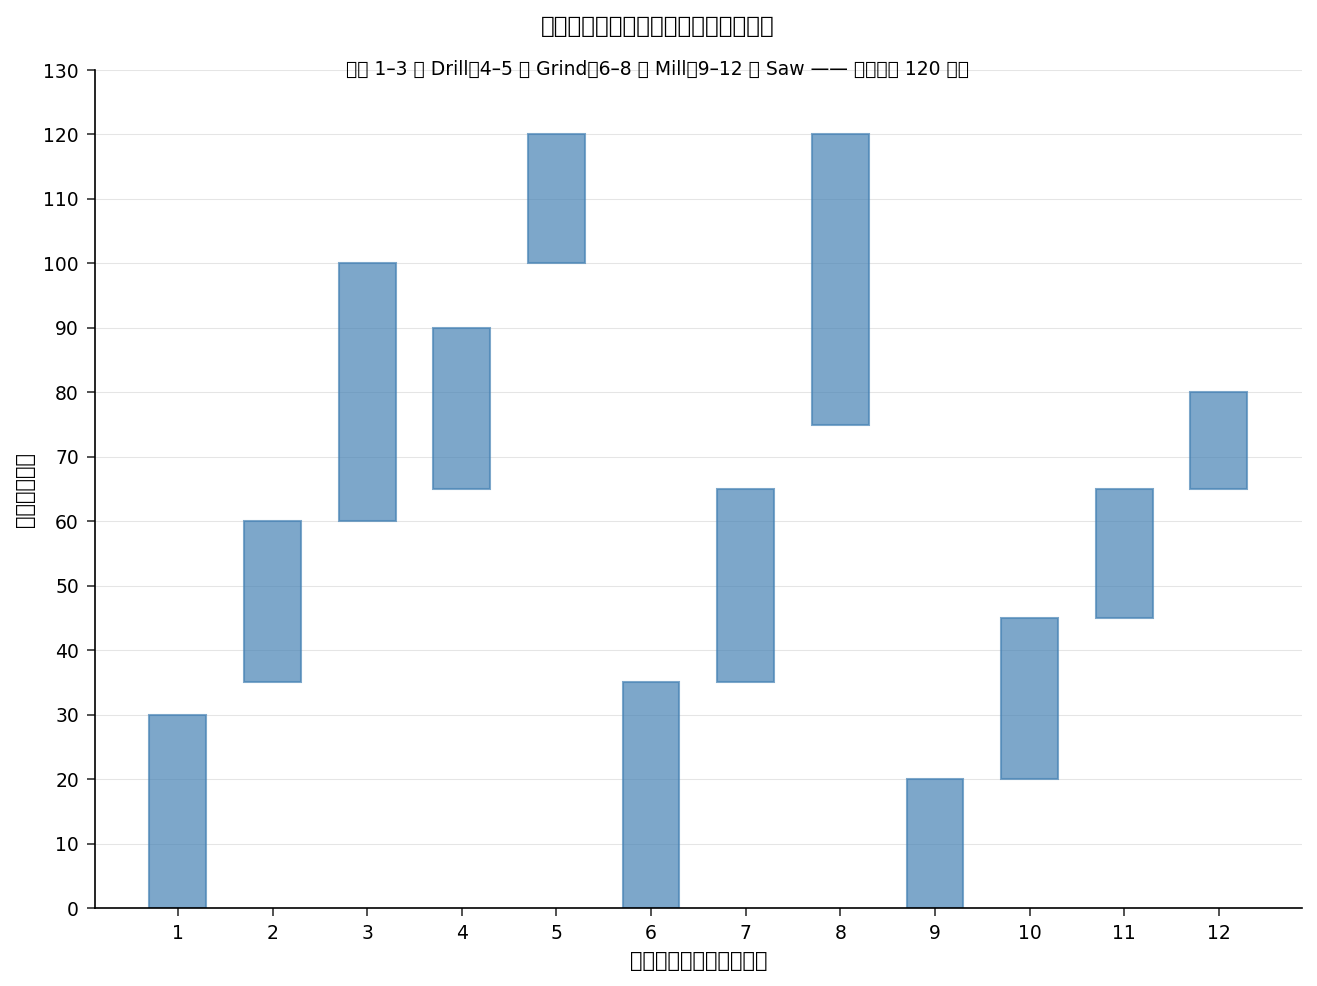

In [4]:
数据 ganttdata;
    设置 schedule;
    slot + 1;
运行;

过程 打印 数据=ganttdata noobs 标签;
    标题 '按槽位排列的调度（槽位顺序与下方图表一致）';
    变量 slot mname jobname START FINISH;
    标签 slot='槽位' mname='机器' jobname='零件'
          START='开始时间' FINISH='结束时间';
运行;

过程 SGPLOT 数据=ganttdata noautolegend;
    标题 '最优作业车间调度：各工序的时间窗口';
    title2 '槽位 1–3 为 Drill，4–5 为 Grind，6–8 为 Mill，9–12 为 Saw —— 完工时间 120 分钟';
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS 标签='工序槽位（按机器分组）' integer
          VALUES=(1 到 12 按照 1);
    YAXIS 标签='时间（分钟）' grid VALUES=(0 到 130 按照 10);
运行;
标题;

## 结果解读

- **最优性。** MILP 求解器返回了 `Solution Status = Optimal`，`Objective Value = 120`，因此对这个实例而言 **120 分钟是可证明的最短完工时间**——没有任何调度能更早完成。这份证书正是数学规划构造相对于纯可行性搜索所带来的价值。

- **调度满足每一条约束。** 阅读按机器排列的表格，同一台机器上的任何两道工序都不重叠（例如在 Saw 上：Shaft 0–20、Bracket 20–45、Housing 45–65、Flange 65–80），并且每个零件都按工艺顺序运行（例如 Housing：Drill 0–30，然后 Saw 45–65，再 Mill 75–120）。浮动条图显示的是同样的结果：在每台机器的槽位带内，各时间窗口互不碰撞地铺排。

- **是什么决定了调度长度。** 有两道工序恰好在第 120 分钟结束——Bracket 的 Grind（槽位 5）和 Housing 的 Mill（槽位 8）。二者都触及完工时间，因此 Grind 和 Mill 这两台机器位于关键路径上；要进一步缩短完工时间，就必须改变实例本身（更快的工序、增加一台机器，或放松先后次序），而不仅仅是重新排序。

- **如何扩展。** 这一构造可以自然地扩大规模：把一台机器作为 `machine` 的另一个取值加入，把零件作为 `jobshop` 的更多行加入，或者通过对 `s[o]` 加界并添加交货期约束来建模投放时间和交货期。若允许一台机器同时运行多个作业（产能 >1），则将成对的析取替换为累积资源约束。同一个 OPTMODEL MILP 随后便可处理更丰富的车间规则，而无需更换求解器。